## ML I Demo I

## K-means process

Partition the data into k clusters by minimizing the sum of squared distances from points to their assigned centroid:

Pick k (here, 3) and choose initial centroids in the feature space.
Visualize data + seeds to build intuition.
Expect different runs (different seeds) to converge to different local optima.

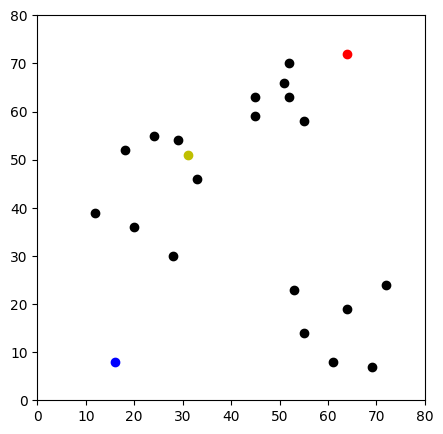

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'x': [12, 20, 28, 18, 29, 33, 24, 45, 45, 52, 51, 52, 55, 53, 55, 61, 64, 69, 72],
    'y': [39, 36, 30, 52, 54, 46, 55, 59, 63, 70, 66, 63, 58, 23, 14, 8, 19, 7, 24]
})

np.random.seed(999)
k = 3
centroids = {
    i+1: [np.random.randint(0, 80), np.random.randint(0, 80)]
    for i in range(k)
} # centroids[i] = [x, y]

fig = plt.figure(figsize=(5, 5))
plt.scatter(df['x'], df['y'], color='k')
colmap = {1: 'r', 2: 'y', 3: 'b', 4: 'g', 5: 'c'}
for i in centroids.keys():
    plt.scatter(*centroids[i], color=colmap[i])
plt.xlim(0, 80)
plt.ylim(0, 80)
plt.show()

#### Assignment Stage

Step 1 —
For each point​, compute its Euclidean distance to every centroid​ and assign every point​ to the cluster with the minimum distance.

This stage produces: Per‑centroid distance columns (one per centroid).
A closest label indicating the chosen cluster.
A color for visualization.
The scatter plot shows how the initial seeds partition the space: each point belongs to the region of the nearest seed

In [2]:
def assignment(df, centroids):
    for i in centroids.keys():
        # sqrt((x1 - x2)^2 - (y1 - y2)^2)
        df['distance_from_{}'.format(i)] = (
            np.sqrt(
                (df['x'] - centroids[i][0]) ** 2
                + (df['y'] - centroids[i][1]) ** 2
            )
        )
    centroid_distance_cols = ['distance_from_{}'.format(i) for i in centroids.keys()]
    df['closest'] = df.loc[:, centroid_distance_cols].idxmin(axis=1)
    df['closest'] = df['closest'].map(lambda x: int(x.lstrip('distance_from_')))
    df['color'] = df['closest'].map(lambda x: colmap[x])
    return df

df = assignment(df, centroids)
print(df.head())

    x   y  distance_from_1  distance_from_2  distance_from_3  closest color
0  12  39        61.587336        22.472205        31.256999        2     y
1  20  36        56.850682        18.601075        28.284271        2     y
2  28  30        55.317267        21.213203        25.059928        2     y
3  18  52        50.159745        13.038405        44.045431        2     y
4  29  54        39.357337         3.605551        47.801674        2     y


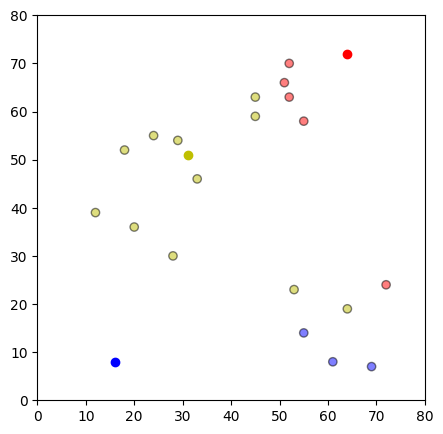

In [3]:
fig = plt.figure(figsize=(5, 5))
plt.scatter(df['x'], df['y'], color=df['color'], alpha=0.5, edgecolor='k')
for i in centroids.keys():
    plt.scatter(*centroids[i], color=colmap[i])
plt.xlim(0, 80)
plt.ylim(0, 80)
plt.show()

#### Update Stage

Update centroids as cluster means. After assignment, recompute each centroid  as the mean of the points currently assigned to cluster j:

This moves centroids toward the center of mass of their clusters. The plot overlays arrows from old to new positions to show the movement toward denser regions.

Empty cluster: if a cluster gets no points, you may need to reinitialize that centroid (e.g., to the farthest point or via k‑means++).
Robustness: means are sensitive to outliers; alternatives include k‑medoids or trimming.

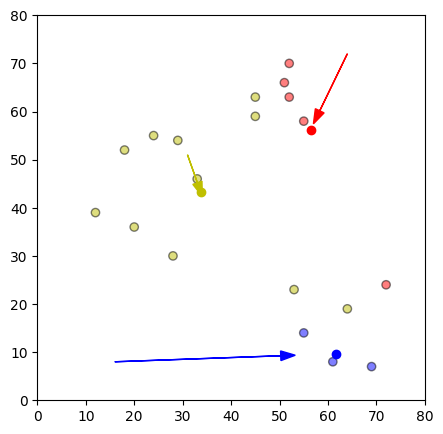

In [4]:
import copy

old_centroids = copy.deepcopy(centroids)

def update(k):
    for i in centroids.keys():
        centroids[i][0] = np.mean(df[df['closest'] == i]['x'])
        centroids[i][1] = np.mean(df[df['closest'] == i]['y'])
    return k

centroids = update(centroids)

fig = plt.figure(figsize=(5, 5))
ax = plt.axes()
plt.scatter(df['x'], df['y'], color=df['color'], alpha=0.5, edgecolor='k')
for i in centroids.keys():
    plt.scatter(*centroids[i], color=colmap[i])
plt.xlim(0, 80)
plt.ylim(0, 80)

for i in old_centroids.keys():
    old_x = old_centroids[i][0]
    old_y = old_centroids[i][1]
    dx = (centroids[i][0] - old_centroids[i][0]) * 0.75
    dy = (centroids[i][1] - old_centroids[i][1]) * 0.75
    ax.arrow(old_x, old_y, dx, dy, head_width=2, head_length=3, fc=colmap[i], ec=colmap[i])
plt.show()

#### Repeat Assigment Stage

The formula for the within-cluster sum of squared means, also known as Inertia, is given by:

$$ \sum_{i=0}^{n}(||x_i - \mu_j||^2) $$

Where:
- $x_i$ is a data point.
- $\mu_j$ is the centroid of cluster $j$.
- $C$ is the set of all centroids.
- $||x_i - \mu_j||^2$ is the squared Euclidean distance between data point $x_i$ and centroid $\mu_j$.

This formula calculates the sum of the squared distances between each data point and the centroid of the cluster it belongs to. The K-means algorithm aims to minimize this value.

Step 3 — Re‑assign with updated centroids
With the new centroids, re‑compute distances and re‑assign points. Assignment ↔ Update forms one iteration. Replot to see how boundaries and colors change. Each iteration reduces (or keeps) the objective (inertia, aka within cluster sum of squared distances)
This monotone decrease continues until assignments stabilize.

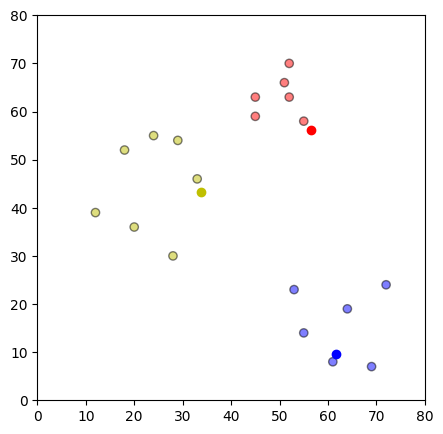

In [5]:
df = assignment(df, centroids)

fig = plt.figure(figsize=(5, 5))
plt.scatter(df['x'], df['y'], color=df['color'], alpha=0.5, edgecolor='k')
for i in centroids.keys():
    plt.scatter(*centroids[i], color=colmap[i])
plt.xlim(0, 80)
plt.ylim(0, 80)
plt.show()

#### Continue until all assigned categories don't change any more

Loop until convergence — stops, when assignments no longer change.
We iterate assignment → update until the cluster labels stop changing (or until the centroid shift is below a tolerance, or we hit max_iter). This implements Lloyd’s algorithm, which converges to a local minimum of the inertia (global optimality is not guaranteed). The final visualization shows clusters and their centroids after convergence.
Practical tips:
* Run multiple initializations and keep the best inertia.
* Consider standardizing features (StandardScaler) when scales differ.
* Track metrics: inertia curve vs. iterations; silhouette score for quality.

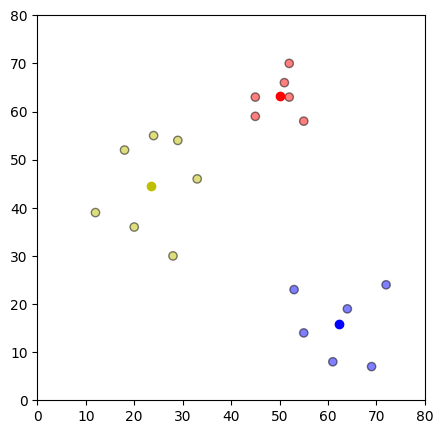

In [6]:
while True:
    closest_centroids = df['closest'].copy(deep=True)
    centroids = update(centroids)
    df = assignment(df, centroids)
    if closest_centroids.equals(df['closest']):
        break

fig = plt.figure(figsize=(5, 5))
plt.scatter(df['x'], df['y'], color=df['color'], alpha=0.5, edgecolor='k')
for i in centroids.keys():
    plt.scatter(*centroids[i], color=colmap[i])
plt.xlim(0, 80)
plt.ylim(0, 80)
plt.show()

#### We can compare it now with Kmeans library from scikit

Now we fit KMeans (n_clusters=3) from scikit‑learn on the same data and plot its labels and cluster_centers_.
scikit‑learn’s implementation uses Lloyd’s algorithm with efficient vectorization and, by default, k‑means++ initialization for more stable results. Comparing our manual implementation to scikit‑learn confirms the workflow and helps validate convergence.

Handy attributes:
* cluster_centers_: final centroids
* labels_: cluster labels for each sample
* inertia_: final objective (sum of squared distances to nearest centroid)

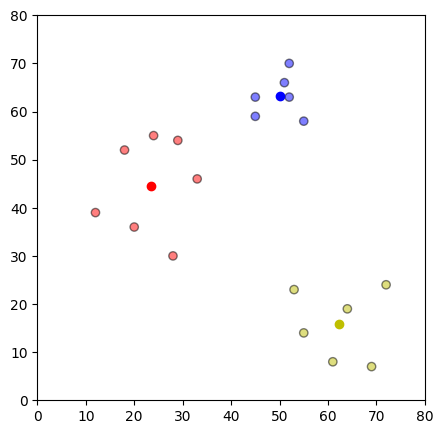

In [9]:
from sklearn.cluster import KMeans

df = pd.DataFrame({
    'x': [12, 20, 28, 18, 29, 33, 24, 45, 45, 52, 51, 52, 55, 53, 55, 61, 64, 69, 72],
    'y': [39, 36, 30, 52, 54, 46, 55, 59, 63, 70, 66, 63, 58, 23, 14, 8, 19, 7, 24]
})

kmeans = KMeans(n_clusters=3)
kmeans.fit(df)
labels = kmeans.predict(df)
centroids = kmeans.cluster_centers_

fig = plt.figure(figsize=(5, 5))

colmap = {1: 'b', 2: 'y', 3: 'r'}
colors = list(map(lambda x: colmap[x+1], labels))

plt.scatter(df['x'], df['y'], color=colors, alpha=0.5, edgecolor='k')
for idx, centroid in enumerate(centroids):
    plt.scatter(*centroid, color=colmap[idx+1])
plt.xlim(0, 80)
plt.ylim(0, 80)
plt.show()

We knew we had three grups. But if you want to calculate the optimal number of groups, you can use the elbow method. Note that this result is orientative. If you have better silhouette with +1 or -1 groups, go ahead.

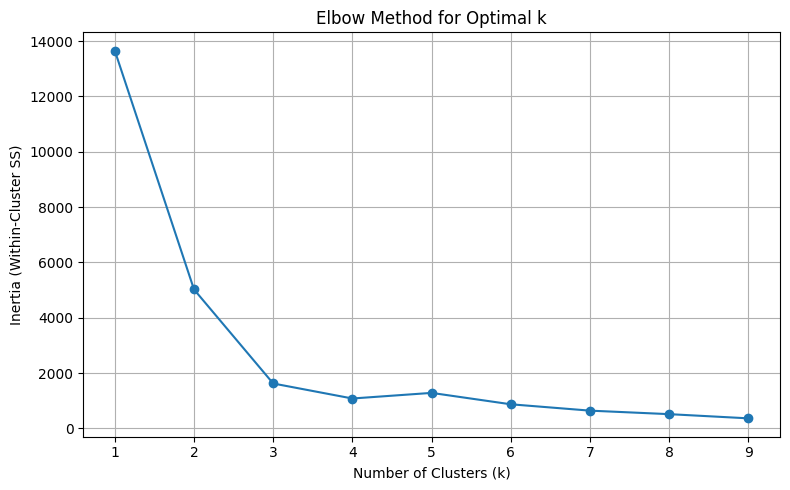

In [10]:
inertias = [] # aka within cluster sum of squared distances
K_values = range(1, 10)
for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8, 5))
plt.plot(K_values, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster SS)')
plt.grid(True)
plt.tight_layout()
plt.show()